In [1]:
import os

os.chdir(r"C:\Users\kutay\Desktop\veri-madenciligi-grup-projesi-main")

print(os.getcwd())
print(os.listdir())

C:\Users\kutay\Desktop\veri-madenciligi-grup-projesi-main
['baseline_results.json', 'hafta1_baseline_grafik.png', 'hafta1_feature_importance.png', 'hafta1_model.py', 'weatherAUS.csv']


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [17]:
print("Satır-sütun:", df.shape)

df.info()

Satır-sütun: (145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Clo

In [18]:
missing_table = pd.DataFrame({
    "Eksik Sayısı": df.isnull().sum(),
    "Eksik Oranı (%)": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Eksik Sayısı", ascending=False)

missing_table.head(15)

,Eksik Sayısı,Eksik Oranı (%)
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [19]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Sayısal kolon sayısı:", len(numeric_cols))
print(numeric_cols)

print("\nKategorik kolon sayısı:", len(categorical_cols))
print(categorical_cols)

Sayısal kolon sayısı: 16
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Kategorik kolon sayısı: 7
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [20]:
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

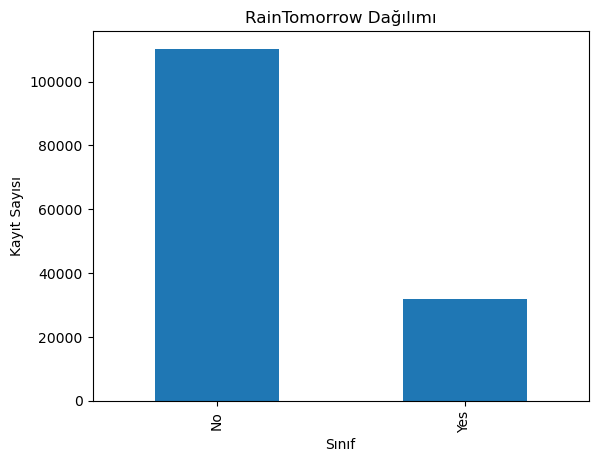

In [21]:
df["RainTomorrow"].value_counts().plot(kind="bar", title="RainTomorrow Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Kayıt Sayısı")
plt.show()

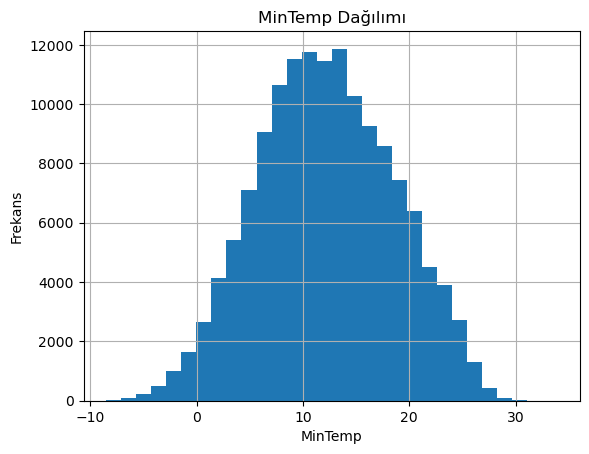

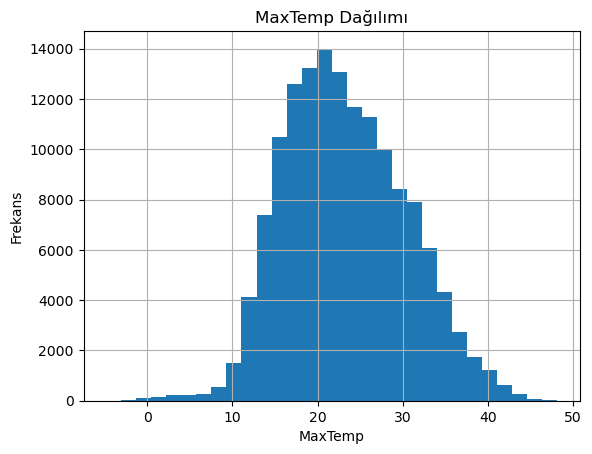

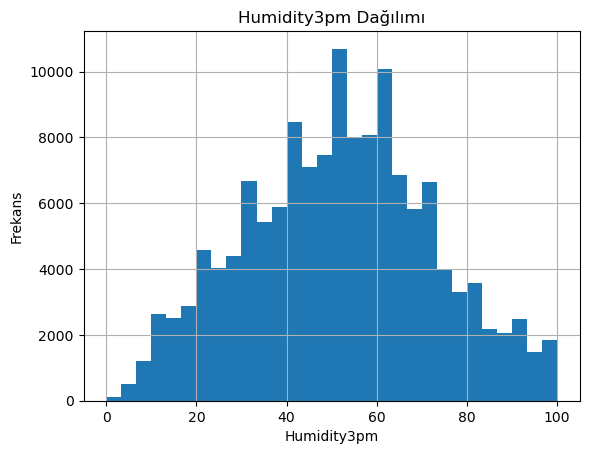

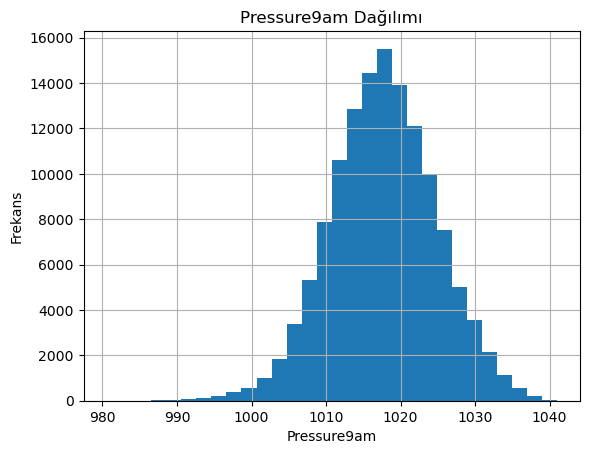

In [22]:
for col in ["MinTemp", "MaxTemp", "Humidity3pm", "Pressure9am"]:
    df[col].hist(bins=30)
    plt.title(f"{col} Dağılımı")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.show()

In [23]:
def add_missing(df, col, ratio=0.1):
    df = df.copy()
    idx = np.random.choice(df.index, int(len(df)*ratio), replace=False)
    df.loc[idx, col] = np.nan
    return df

In [24]:
def add_outlier(df, col):
    df = df.copy()
    df[col] = df[col] * np.random.uniform(1, 3, size=len(df))
    return df

In [25]:
df_missing = add_missing(df, "Humidity3pm", 0.1)

df_outlier = add_outlier(df, "Temp3pm")

df_both = add_outlier(df_missing, "Pressure9am")

In [26]:
df_missing.to_csv("data_missing.csv", index=False)
df_outlier.to_csv("data_outlier.csv", index=False)
df_both.to_csv("data_both.csv", index=False)

In [27]:
import os

print(os.listdir())

print("Orijinal:", df.shape)
print("Missing:", df_missing.shape)
print("Outlier:", df_outlier.shape)
print("Both:", df_both.shape)

print("\nHumidity3pm eksik sayısı:")
print("Orijinal:", df["Humidity3pm"].isnull().sum())
print("Missing:", df_missing["Humidity3pm"].isnull().sum())

print("\nTemp3pm özet:")
print("Orijinal:")
print(df["Temp3pm"].describe())

print("\nOutlier:")
print(df_outlier["Temp3pm"].describe())

['baseline_results.json', 'data_both.csv', 'data_missing.csv', 'data_outlier.csv', 'hafta1_baseline_grafik.png', 'hafta1_feature_importance.png', 'hafta1_model.py', 'weatherAUS.csv']
Orijinal: (145460, 23)
Missing: (145460, 23)
Outlier: (145460, 23)
Both: (145460, 23)

Humidity3pm eksik sayısı:
Orijinal: 4507
Missing: 18603

Temp3pm özet:
Orijinal:
count    141851.00000
mean         21.68339
std           6.93665
min          -5.40000
25%          16.60000
50%          21.10000
75%          26.40000
max          46.70000
Name: Temp3pm, dtype: float64

Outlier:
count    141851.000000
mean         43.336669
std          19.089826
min         -15.655457
25%          28.992626
50%          40.324750
75%          54.926015
max         129.044710
Name: Temp3pm, dtype: float64
